# 04. Interpretabilidad (Fase 4, pregunta 1)

**Pregunta:** ¿qué características del tráfico distinguen un ataque del tráfico
normal, y cuáles son las más informativas?

Trabajamos sobre el problema **binario** (Normal vs Ataque), solo con el conjunto de
**entrenamiento** (el test sigue intacto), las mismas 48 features y la semilla 42.

El análisis tiene tres partes:
1. **Una lectura sencilla:** los coeficientes de la regresión logística estandarizada
   (un modelo lineal simple que cualquiera puede leer).
2. **El modelo real:** la importancia por permutación sobre el mejor modelo de la Fase 3
   (árboles + pesos de clase). Si al barajar una feature el desempeño cae, quiere decir
   que el modelo dependía de ella.
3. **La verificación de validez:** el experimento del puerto de destino, para saber si
   el modelo aprende el *comportamiento* del tráfico o si se apoya en un *artefacto del
   dataset*.

> **Nota:** el cómputo pesado (5 ajustes de la logística, la permutación y el
> reentrenamiento sin puerto) se hizo una sola vez con `python -m src.interpretabilidad`
> (con checkpoints). Este notebook solo lee los CSVs de `reports/resultados_fase4/`.

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RUTA_FIGURAS
from src.interpretabilidad import RUTA_EXPORT

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

coef = pd.read_csv(RUTA_EXPORT / "q1_coeficientes_logistica.csv")
perm = pd.read_csv(RUTA_EXPORT / "q1_importancia_permutacion.csv")
puerto_f1 = pd.read_csv(RUTA_EXPORT / "q1_puerto_macro_f1.csv")
puerto_recall = pd.read_csv(RUTA_EXPORT / "q1_puerto_recall_por_clase.csv")
puerto_precision = pd.read_csv(RUTA_EXPORT / "q1_puerto_precision_por_clase.csv")
print("Resultados cargados")

Resultados cargados


## 1. Una lectura sencilla: coeficientes de la regresión logística

Como las features están estandarizadas, la **magnitud** de cada coeficiente se puede
comparar entre features, y el **signo** dice hacia dónde empuja: si es positivo empuja
hacia "Ataque" y si es negativo hacia "Normal". Se reporta la media ± la desviación
entre los 5 ajustes (uno por partición), y una desviación pequeña indica que el ranking
es estable.

In [2]:
top_coef = coef.head(15).copy()
top_coef["dirección"] = np.where(top_coef["coef_media"] > 0, "→ Ataque", "→ Normal")
top_coef.round(3)

,feature,coef_media,coef_desv,dirección
0,Fwd IAT Mean,-11.969,0.852,→ Normal
1,Fwd IAT Min,11.469,0.757,→ Ataque
2,Packet Length Variance,11.265,0.424,→ Ataque
3,Flow IAT Max,-9.329,0.831,→ Normal
4,Init_Win_bytes_forward_no_aplica,-8.651,0.088,→ Normal
5,Fwd IAT Std,8.550,0.543,→ Ataque
6,Fwd Packet Length Max,-6.639,0.296,→ Normal
7,Flow Duration,5.148,0.402,→ Ataque
8,Flow IAT Std,5.008,0.569,→ Ataque
9,Active Max,-4.981,0.325,→ Normal


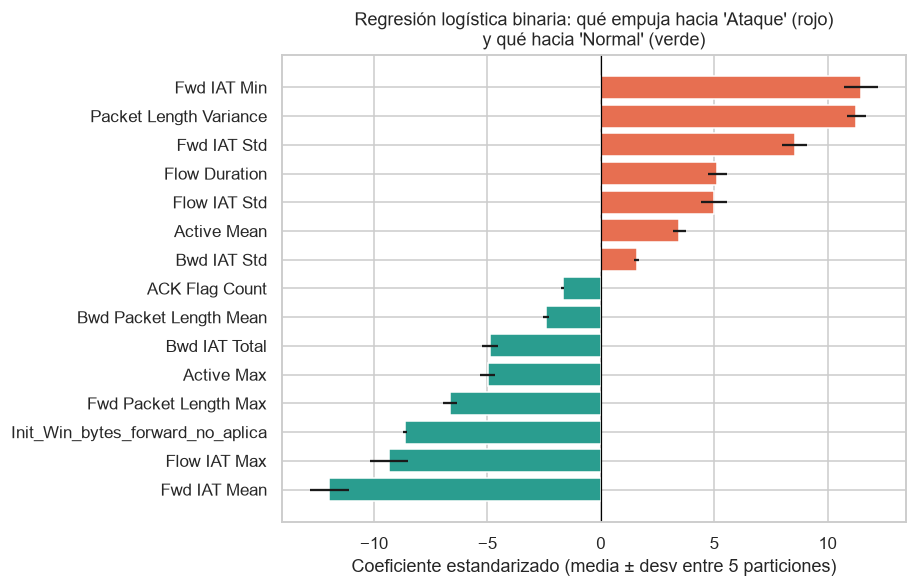

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
datos = top_coef.sort_values("coef_media")
colores = ["#e76f51" if c > 0 else "#2a9d8f" for c in datos["coef_media"]]
ax.barh(datos["feature"], datos["coef_media"], xerr=datos["coef_desv"], color=colores)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coeficiente estandarizado (media ± desv entre 5 particiones)")
ax.set_title("Regresión logística binaria: qué empuja hacia 'Ataque' (rojo)\n"
             "y qué hacia 'Normal' (verde)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "11_coeficientes_logistica.png", bbox_inches="tight")
plt.show()

**Lectura en lenguaje sencillo.** La logística se fija sobre todo en el **ritmo** del tráfico:

- Las features `IAT` (*inter-arrival time*) miden el silencio entre paquetes
  consecutivos. El patrón conjunto (silencio promedio bajo, con el mínimo y la
  variabilidad empujando en sentido contrario) describe ráfagas automatizadas con un
  ritmo muy regular, típicas de las herramientas de ataque, frente al ritmo irregular de
  una persona navegando.
- `Packet Length Variance` (+): los paquetes de tamaños muy variables apuntan a un
  ataque, mientras que el tráfico normal de una aplicación suele tener tamaños más
  parecidos.
- `Init_Win_bytes_forward_no_aplica` (−): el indicador que creamos en la limpieza (a
  partir del −1 de "no aplica") empuja hacia Normal. Que sea informativo por sí mismo
  confirma que valía la pena tratarlo como un código y no como un número.
- `Flow Duration` (+): conversaciones anormalmente largas (como los ataques "lentos"
  tipo slowloris, que dejan conexiones abiertas a propósito).

## 2. El modelo real: importancia por permutación (árboles + pesos)

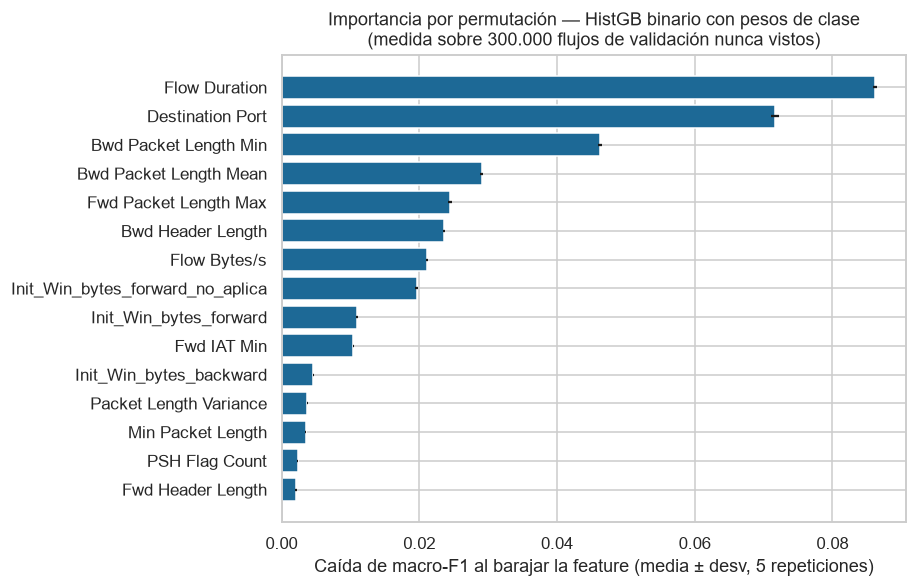

,feature,importancia_media,importancia_desv
0,Flow Duration,0.0862,0.0002
1,Destination Port,0.0716,0.0006
2,Bwd Packet Length Min,0.0463,0.0003
3,Bwd Packet Length Mean,0.0291,0.0002
4,Fwd Packet Length Max,0.0245,0.0002
5,Bwd Header Length,0.0236,0.0002
6,Flow Bytes/s,0.0212,0.0001
7,Init_Win_bytes_forward_no_aplica,0.0196,0.0002
8,Init_Win_bytes_forward,0.0110,0.0002
9,Fwd IAT Min,0.0104,0.0001


In [4]:
top_perm = perm.head(15)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
datos = top_perm.sort_values("importancia_media")
ax.barh(datos["feature"], datos["importancia_media"],
        xerr=datos["importancia_desv"], color="#1d6996")
ax.set_xlabel("Caída de macro-F1 al barajar la feature (media ± desv, 5 repeticiones)")
ax.set_title("Importancia por permutación — HistGB binario con pesos de clase\n"
             "(medida sobre 300.000 flujos de validación nunca vistos)")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "12_importancia_permutacion.png", bbox_inches="tight")
plt.show()
top_perm.round(4)

In [5]:
# ¿Coinciden los dos rankings?
top_n = 12
en_logistica = set(coef.head(top_n)["feature"])
en_permutacion = set(perm.head(top_n)["feature"])
comunes = sorted(en_logistica & en_permutacion)
print(f"Features en el top-{top_n} de AMBOS rankings ({len(comunes)}):")
for f in comunes:
    print(f"  - {f}")
print(f"\nSolo en la logística: {sorted(en_logistica - en_permutacion)}")
print(f"Solo en la permutación: {sorted(en_permutacion - en_logistica)}")

Features en el top-12 de AMBOS rankings (5):
  - Flow Duration
  - Fwd IAT Min
  - Fwd Packet Length Max
  - Init_Win_bytes_forward_no_aplica
  - Packet Length Variance

Solo en la logística: ['Active Max', 'Active Mean', 'Bwd IAT Total', 'Flow IAT Max', 'Flow IAT Std', 'Fwd IAT Mean', 'Fwd IAT Std']
Solo en la permutación: ['Bwd Header Length', 'Bwd Packet Length Mean', 'Bwd Packet Length Min', 'Destination Port', 'Flow Bytes/s', 'Init_Win_bytes_backward', 'Init_Win_bytes_forward']


**Comparación de los dos rankings.** Coinciden en lo principal (duración del flujo,
ritmo entre paquetes, tamaño máximo del paquete de ida y el indicador de "no aplica"),
lo que da confianza, porque dos modelos muy distintos señalan las mismas señales de
comportamiento. Donde difieren es en el énfasis: la logística, que solo puede trazar
fronteras lineales, se apoya sobre todo en el *ritmo* (IAT), mientras que los árboles
reparten el peso entre el *tamaño de los paquetes de respuesta* (`Bwd Packet Length
Min/Mean`) y **`Destination Port`, que queda en el puesto 2**. Esto último es lo que nos
lleva a la verificación de la sección 3.

### Ranking de features con su explicación

| # | Feature | Por qué tiene sentido que delate un ataque |
|---|---|---|
| 1 | `Flow Duration` | Los ataques tienen duraciones poco comunes: o milisegundos (escaneos, fuerza bruta) o muchísimo tiempo (DoS lentos que dejan la conexión abierta). |
| 2 | `Destination Port` | La "puerta" del servicio atacado. Depende de cómo se montó el dataset más que del comportamiento del tráfico (ver sección 3). |
| 3 | `Bwd Packet Length Min/Mean` | El tamaño de las respuestas del servidor: un servidor bajo ataque responde con paquetes atípicos (errores, respuestas vacías). |
| 4 | `Fwd Packet Length Max` | El paquete más grande que envía el origen: las herramientas automatizadas mandan peticiones pequeñas y repetitivas. |
| 5 | `Flow Bytes/s` | La "velocidad de descarga" de la conversación: los DoS inundan al servidor y los escaneos casi no transfieren datos. |
| 6 | `Fwd IAT Mean/Min` | El silencio entre paquetes: las máquinas envían con un ritmo rápido y muy regular, mientras que las personas lo hacen a un ritmo irregular. |
| 7 | `Init_Win_bytes_forward(_no_aplica)` | Cómo se abre la conexión TCP: las herramientas de ataque la configuran distinto a un navegador normal. |
| 8 | `Packet Length Variance` | Tamaños de paquete muy distintos dentro de una misma conversación son poco comunes en el tráfico normal de una aplicación. |

## 3. La verificación de validez: el experimento del puerto

`Destination Port` es el único identificador entre las 48 features. En este dataset
cada ataque usa sus puertos típicos (el ataque web el 80, SSH el 22, etc.), pero **en
el mundo real nada obliga a que sea así**. Un modelo que se apoye en el puerto estaría
aprendiendo cómo se montó el experimento en lugar del comportamiento del ataque. Para
comprobarlo reentrenamos el mejor modelo multiclase (árboles + pesos, mismas
particiones) **sin** esa feature.

In [6]:
resumen_f1 = puerto_f1.groupby("variante")["macro_f1"].agg(["mean", "std"]).round(3)
print("macro-F1 (5 particiones):")
print(resumen_f1.to_string())

rec = puerto_recall.pivot_table(index="clase", columns="variante", values="media").round(3)
rec["delta_recall"] = (rec["sin_puerto"] - rec["con_puerto"]).round(3)
prec = puerto_precision.pivot_table(index="clase", columns="variante", values="media").round(3)
prec["delta_precision"] = (prec["sin_puerto"] - prec["con_puerto"]).round(3)

comparacion = pd.concat(
    {"recall": rec, "precisión": prec}, axis=1
).sort_values(("precisión", "delta_precision"))
comparacion

macro-F1 (5 particiones):
            mean    std
variante               
con_puerto  0.97  0.002
sin_puerto  0.95  0.004


recall                          precisión             \
variante         con_puerto sin_puerto delta_recall con_puerto sin_puerto   
clase                                                                       
Bot                   0.980      0.984        0.004      0.614      0.461   
Web Attack            0.987      0.985       -0.002      0.952      0.872   
DoS Slowhttptest      0.994      0.994        0.000      0.977      0.926   
DoS slowloris         0.996      0.996        0.000      0.976      0.962   
DoS Hulk              0.999      0.999        0.000      0.992      0.986   
FTP-Patator           1.000      0.998       -0.002      0.999      0.994   
DoS GoldenEye         0.998      0.998        0.000      0.982      0.979   
PortScan              1.000      1.000        0.000      0.989      0.987   
SSH-Patator           1.000      0.995       -0.005      0.997      0.995   
DDoS                  1.000      1.000        0.000      1.000      0.999   
BENIGN                0.998      0.997       -0.001      1.000      1.000   

                                  
variante         delta_precision  
clase                             
Bot                       -0.153  
Web Attack                -0.080  
DoS Slowhttptest          -0.051  
DoS slowloris             -0.014  
DoS Hulk                  -0.006  
FTP-Patator               -0.005  
DoS GoldenEye             -0.003  
PortScan                  -0.002  
SSH-Patator               -0.002  
DDoS                      -0.001  
BENIGN                     0.000

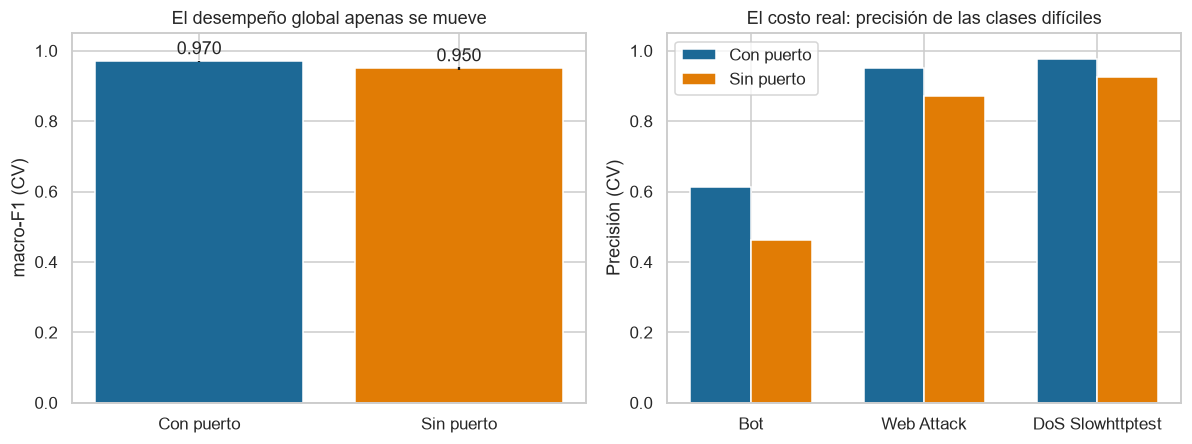

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(["Con puerto", "Sin puerto"], resumen_f1.loc[["con_puerto", "sin_puerto"], "mean"],
            yerr=resumen_f1.loc[["con_puerto", "sin_puerto"], "std"],
            color=["#1d6996", "#e17c05"])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("macro-F1 (CV)")
axes[0].set_title("El desempeño global apenas se mueve")
for i, v in enumerate(resumen_f1.loc[["con_puerto", "sin_puerto"], "mean"]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

clases_foco = ["Bot", "Web Attack", "DoS Slowhttptest"]
x = np.arange(len(clases_foco))
ancho = 0.35
axes[1].bar(x - ancho / 2, prec.loc[clases_foco, "con_puerto"], ancho,
            label="Con puerto", color="#1d6996")
axes[1].bar(x + ancho / 2, prec.loc[clases_foco, "sin_puerto"], ancho,
            label="Sin puerto", color="#e17c05")
axes[1].set_xticks(x, clases_foco)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Precisión (CV)")
axes[1].set_title("El costo real: precisión de las clases difíciles")
axes[1].legend()

fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "13_experimento_puerto.png", bbox_inches="tight")
plt.show()

## Resultado del experimento del puerto

- **El modelo sigue funcionando sin el puerto, así que usa el comportamiento.** El
  macro-F1 pasa de 0,970 ± 0,002 a 0,950 ± 0,004 al quitar `Destination Port`. El
  **recall se mantiene en todas las clases** (la mayor caída es de 0,005 en SSH-Patator,
  y Bot incluso sube 0,004), es decir, el modelo sigue *encontrando* los ataques por su
  comportamiento.
- **El costo está en la precisión de las dos clases difíciles:** la precisión de Bot
  baja de 0,61 a 0,46 y la de Web Attack de 0,95 a 0,87. Sin el puerto como pista, el
  modelo confunde más tráfico benigno con esas dos clases. Es decir, la detección no
  dependía del puerto, pero el puerto sí ayudaba a *descartar falsas alarmas* en las
  clases minoritarias más difíciles.
- **Implicación para la tesis:** los resultados principales no dependen del artefacto.
  Aun así, para un despliegue real conviene reportar las dos variantes, porque la versión
  sin puerto es la estimación más realista de lo que funcionaría en una red donde los
  servicios no usen sus puertos típicos.